In [1]:
# Import libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json # unpack dictionaries
import joblib # saved the scalar with joblib

import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             f1_score, confusion_matrix, roc_curve,
                             matthews_corrcoef)
from torch.utils.data import Dataset, DataLoader

In [2]:
# Load saved artifacts
with open('saved/col_lists.json', 'r') as f:
    cols = json.load(f)

demo_cols = [c for c in cols['demo_cols'] if c not in ['SLQ300', 'SLQ310']]
disease_cols = cols['disease_cols']
demo_meta = cols['demo_meta'] # meta cols are mappings cols for human readable names of the different codes
disease_meta = cols['disease_meta']

# Load data and scaler
data = pd.read_csv('saved/nhanes_clean.csv')
scaler = joblib.load('saved/demo_scaler.pkl')

continuous_cols = ['RIDAGEYR', 'BMXBMI', 'BMXWAIST',
                   'ALQ121', 'PAQ706', 'OCQ180', 'HUQ010', 'SBP', 'DBP']

data[continuous_cols] = scaler.transform(data[continuous_cols])  # transform only, never refit
data[demo_cols] = data[demo_cols].astype(float)
data[disease_cols] = data[disease_cols].astype(float)

# Recreate exact same split as in model.ipynb
train_df, temp_df = train_test_split(data, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

# Load MTL test predictions
test_preds = np.load('saved/mtl_test_preds.npy')
test_targets = np.load('saved/mtl_test_targets.npy')

In [3]:
"""
Below we are reloading a number of classes and the model, to prepare for evaluation.

Really, I ought to create a model.py file where I store all this so it can be easily 
called upon, rather than rewriting from model.ipynb.
"""

# Dataset and DataLoader
class NHANESDataset(Dataset):
    def __init__(self, df, demo_cols, disease_cols):
        self.X = torch.tensor(df[demo_cols].values, dtype=torch.float32)
        self.D = torch.tensor(df[disease_cols].values, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.D[idx]

test_loader = DataLoader(NHANESDataset(test_df, demo_cols, disease_cols),
                         batch_size=64, shuffle=False)

# Load MTL model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class MaskedMTLNet(nn.Module):
    def __init__(self, d_demo, K, H=128, dropout=0.3, circular_pairs=None):
        super().__init__()
        self.K = K
        self.circular_pairs = circular_pairs or {}
        self.trunk = nn.Sequential(
            nn.Linear(d_demo, H), nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H),     nn.BatchNorm1d(H), nn.ReLU(), nn.Dropout(dropout),
        )
        self.heads = nn.ModuleList()
        for k in range(K):
            n_masked = 1 + len(self.circular_pairs.get(k, []))
            self.heads.append(nn.Sequential(
                nn.Linear(H + (K - n_masked), H // 2), nn.ReLU(),
                nn.Linear(H // 2, 1), nn.Sigmoid()
            ))
    def forward(self, x_demo, d):
        h = self.trunk(x_demo)
        preds = []
        for k in range(self.K):
            exclude  = {k} | set(self.circular_pairs.get(k, []))
            keep     = [j for j in range(self.K) if j not in exclude]
            d_input  = torch.nan_to_num(d[:, keep].clone(), nan=0.0)
            preds.append(self.heads[k](torch.cat([h, d_input], dim=1)))
        return torch.cat(preds, dim=1)

# Loading the checkpoint dictionary with all values we used for the model e.g. H is 128 and dropout is 0.3
checkpoint = torch.load('saved/mtl_model.pt', map_location=device)
# This builds the right architecture again:
model = MaskedMTLNet(
    d_demo=checkpoint['d_demo'], K=checkpoint['K'],
    H=checkpoint['H'],           dropout=checkpoint['dropout'],
    circular_pairs=checkpoint['circular_pairs']
).to(device)
# The below pours the trained weights:
model.load_state_dict(checkpoint['model_state_dict'])
# This switches the model to evaluation mode:
model.eval()

# Quick checks
print(f"Test set: {test_preds.shape[0]} samples, {test_preds.shape[1]} diseases")
print(f"Demo features: {len(demo_cols)}")
print(f"Device: {device}")

Test set: 1091 samples, 15 diseases
Demo features: 23
Device: cpu


In [4]:
"""
We have now loaded all the relevant artifacts and got the model ready for 
evaluation state, thus will proceed with deriving the evaluation metrics.
"""

'\nWe have now loaded all the relevant artifacts and got the model ready for \nevaluation state, thus will proceed with deriving the evaluation metrics.\n'

In [5]:
# Evaluation the test set metrics 
def compute_metrics(t, p, thresh): # function to iterate all metrics, t = ground truth and p = prediction
    pred_binary = (p >= thresh).astype(int) # converting some probabilites to binary (0 or 1) depending on threshold
    tn, fp, fn, tp = confusion_matrix(t, pred_binary, labels=[0,1]).ravel() # flattened confusion matrix
    return {
        'prauc': average_precision_score(t, p), # what is the area under our ability to identify correctly > 0.5
        'auroc': roc_auc_score(t, p), # area under where we are able to identify and miss, > prevalence
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0.0, # for a thresh, how well can we recall TPs given FN
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0, # for a thresh, how well do we miss, vs FPs
        'f1': f1_score(t, pred_binary, zero_division=0), # precision and recall combo
        'mcc': matthews_corrcoef(t, pred_binary), # combines all 4 TP,TN,FP,FN for a given threshold
        'threshold': thresh, # threhsold where we decide to categorise for confusion matrix
        'prevalence': t.mean(),
    }

# Function to define the optimal threshold used in ROC as per Youden (1950):
def optimal_threshold(t, p): 
    fpr, tpr, thresholds = roc_curve(t, p)
    return thresholds[np.argmax(tpr - fpr)] # Youden threshold

# display all metrics
def print_metrics(all_targets, all_preds, disease_cols, disease_meta, threshold_method='youden'):
    print(f"Threshold: {'Youden J' if threshold_method == 'youden' else '0.5'}\n")
    print(f"{'Disease':30s}  {'PRAUC':>6}  {'AUROC':>6}  {'Sens':>6}  {'Spec':>6}  {'F1':>6}  {'MCC':>6}  {'Thresh':>6}  {'Prev':>6}") # 6 chars wide
    macro = {k: [] for k in ['prauc', 'auroc', 'sensitivity', 'specificity', 'f1', 'mcc']} # what to print

    for k, col in enumerate(disease_cols):
        valid = ~np.isnan(all_targets[:, k])
        if valid.sum() == 0:
            continue
        t = all_targets[valid, k]
        p = all_preds[valid, k]
        thresh = optimal_threshold(t, p) if threshold_method == 'youden' else 0.5
        m = compute_metrics(t, p, thresh)
        for key in macro:
            macro[key].append(m[key])
        print(f"  {disease_meta[col]:30s}  {m['prauc']:6.3f}  {m['auroc']:6.3f}  "
              f"{m['sensitivity']:6.3f}  {m['specificity']:6.3f}  "
              f"{m['f1']:6.3f}  {m['mcc']:6.3f}  {m['threshold']:6.3f}  {m['prevalence']:6.3f}")
    print(f"  {'Macro average':30s}  {np.mean(macro['prauc']):6.3f}  {np.mean(macro['auroc']):6.3f}  "
          f"{np.mean(macro['sensitivity']):6.3f}  {np.mean(macro['specificity']):6.3f}  "
          f"{np.mean(macro['f1']):6.3f}  {np.mean(macro['mcc']):6.3f}")


print_metrics(test_targets, test_preds, disease_cols, disease_meta, threshold_method='youden')
print()
print_metrics(test_targets, test_preds, disease_cols, disease_meta, threshold_method='fixed')

Threshold: Youden J

Disease                          PRAUC   AUROC    Sens    Spec      F1     MCC  Thresh    Prev
  Diabetes                         0.451   0.885   0.795   0.846   0.506   0.469   0.159   0.103
  Pre-diabetes                     0.369   0.797   0.714   0.754   0.398   0.327   0.214   0.116
  Hypertension                     0.746   0.855   0.754   0.806   0.711   0.546   0.437   0.346
  High cholesterol                 0.705   0.817   0.812   0.694   0.699   0.490   0.421   0.374
  Arthritis                        0.667   0.818   0.806   0.678   0.643   0.450   0.324   0.315
  Congestive heart failure         0.405   0.945   0.920   0.883   0.317   0.389   0.064   0.029
  Coronary heart disease           0.417   0.891   0.878   0.741   0.252   0.293   0.029   0.048
  Heart attack                     0.269   0.869   0.806   0.792   0.247   0.284   0.028   0.042
  Stroke                           0.190   0.813   0.889   0.625   0.171   0.211   0.025   0.042
  Liver con

In [6]:
# Permutation feature importance
"""
I do simple feature importance here (not SHAP), where I shuffle the values of each 
variables, keeping all other variables constant, andn then look at the AUROC drop.
"""
def head_feature_importance(model, loader, demo_cols, disease_cols, n_repeats=10, device='cpu'):
    model.eval()
    K = len(disease_cols)
    all_feats = demo_cols + disease_cols
    n_feats = len(all_feats)
    n_demo = len(demo_cols)

    # Baseline predictions
    def get_preds(x_demo, d):
        with torch.no_grad():
            return model(x_demo, d).cpu().numpy()

    base_preds, all_targets = [], []
    for x_demo, d in loader:
        base_preds.append(get_preds(x_demo.to(device), d.to(device)))
        all_targets.append(d.numpy())

    base_preds  = np.concatenate(base_preds,  axis=0) # (N, K)
    all_targets = np.concatenate(all_targets, axis=0) # (N, K)

    # baseline AUROC per head
    base_auroc = np.zeros(K)
    for k in range(K):
        valid = ~np.isnan(all_targets[:, k])
        if valid.sum() > 0:
            base_auroc[k] = roc_auc_score(all_targets[valid, k], base_preds[valid, k])

    # Permute each feature and measure AUROC drop
    importance = np.zeros((K, n_feats)) # rows = targets, cols = features

    for f_idx in range(n_feats):
        auroc_drops = np.zeros((n_repeats, K))

        for r in range(n_repeats):
            perm_preds = []
            for x_demo, d in loader:
                x_demo, d = x_demo.clone(), d.clone()

                if f_idx < n_demo: # permute a demo feature
                    perm = torch.randperm(x_demo.size(0))
                    x_demo[:, f_idx] = x_demo[perm, f_idx]
                else: # permute a disease flag
                    d_idx = f_idx - n_demo
                    perm = torch.randperm(d.size(0))
                    d[:, d_idx] = d[perm, d_idx]

                perm_preds.append(get_preds(x_demo.to(device), d.to(device)))

            perm_preds = np.concatenate(perm_preds, axis=0)

            for k in range(K):
                valid = ~np.isnan(all_targets[:, k])
                if valid.sum() > 0:
                    perm_auroc = roc_auc_score(
                        all_targets[valid, k], perm_preds[valid, k]
                    )
                    auroc_drops[r, k] = base_auroc[k] - perm_auroc

        importance[:, f_idx] = auroc_drops.mean(axis=0)

    return importance, all_feats, base_auroc


importance_matrix, all_feats, base_auroc = head_feature_importance(
    model, test_loader, demo_cols, disease_cols, n_repeats=10
)

np.save('saved/importance_matrix.npy', importance_matrix)
print("Importance matrix saved — shape:", importance_matrix.shape)

Importance matrix saved — shape: (15, 38)


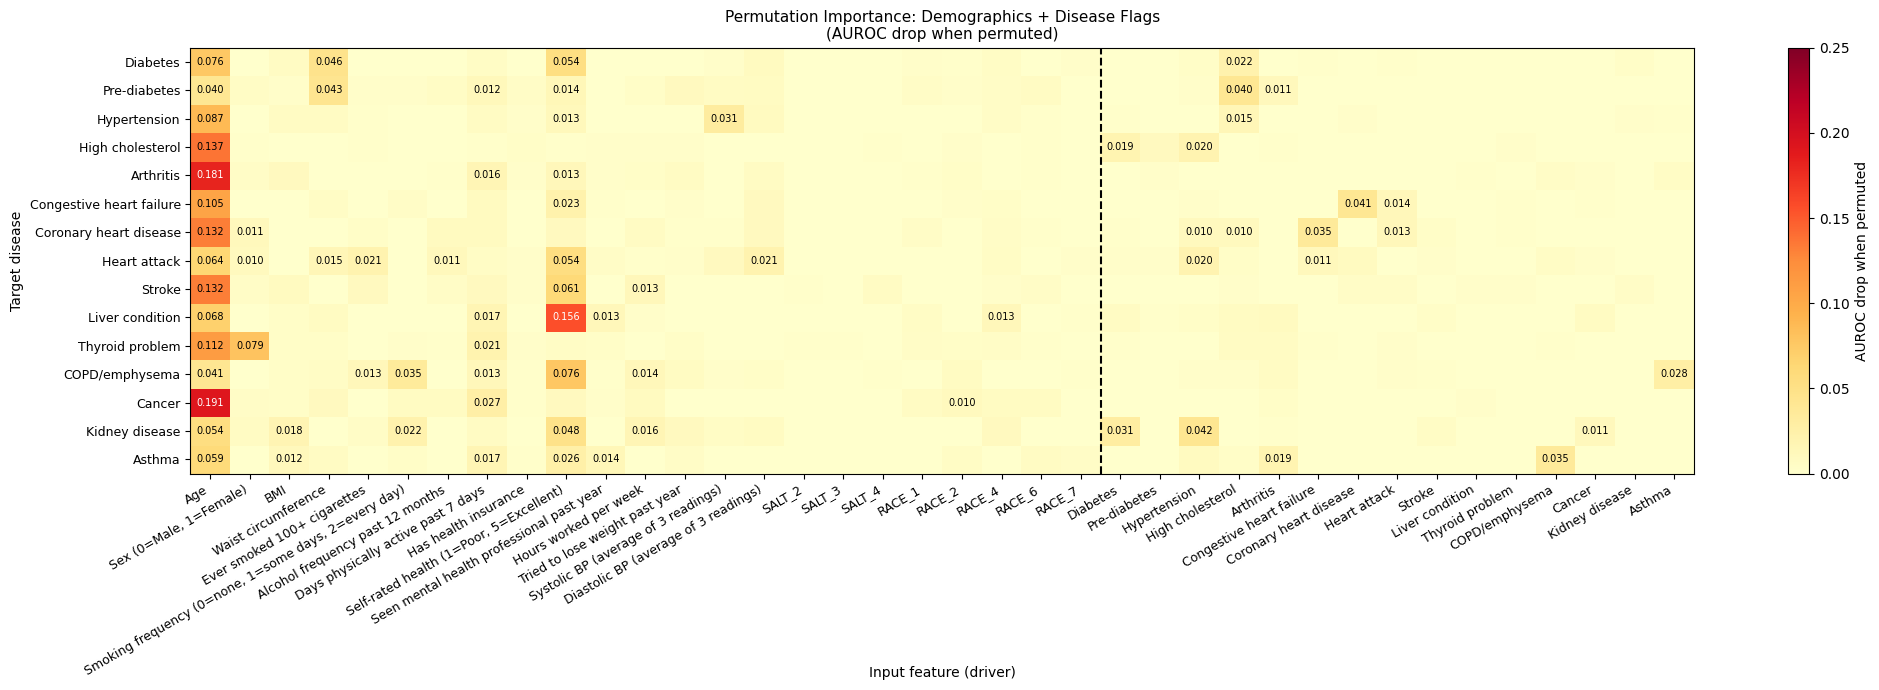

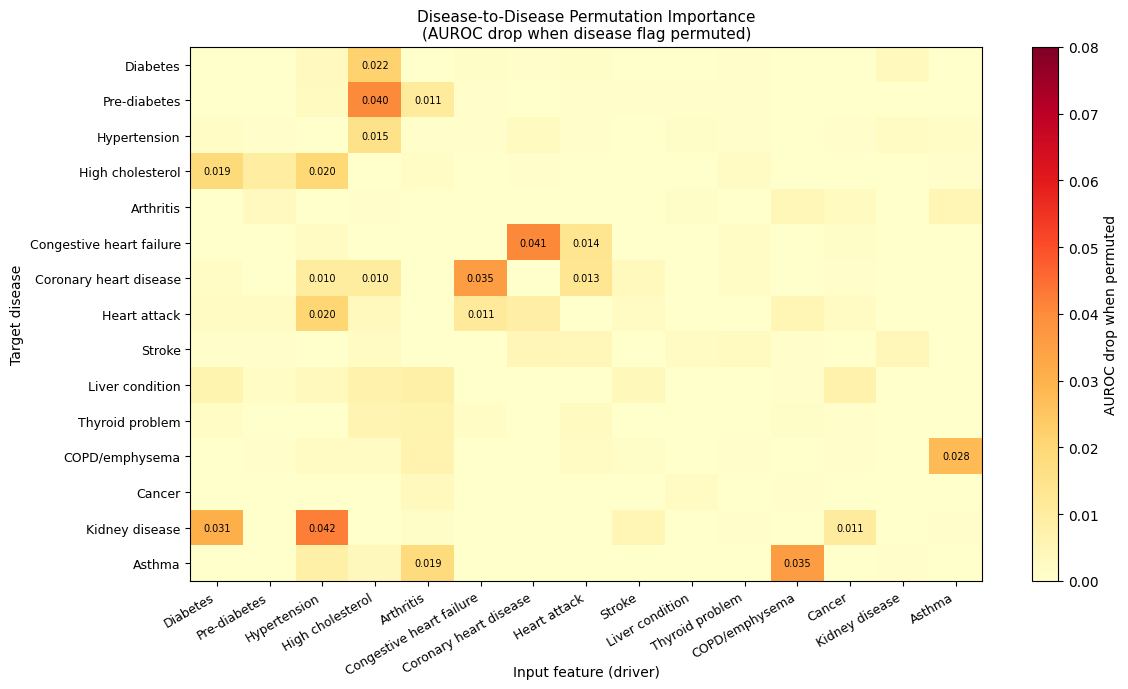

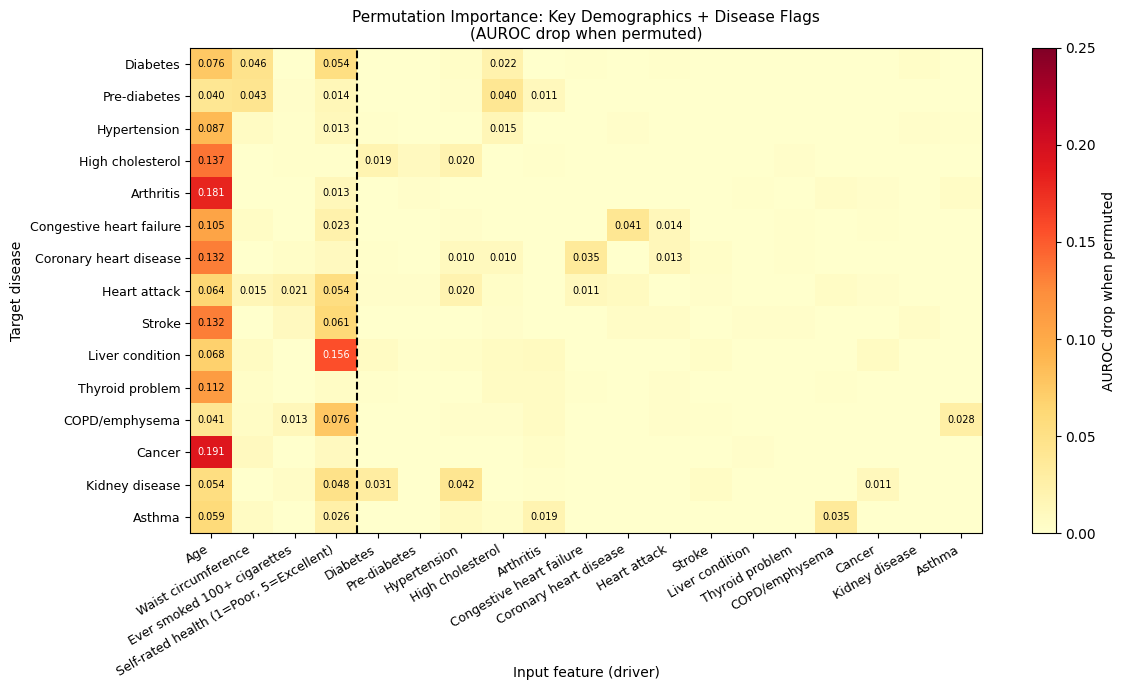

In [7]:
# Plotting three importance heatmaps
"""
I opt for the following three representations, where the second will be
included in my report:
    1. all features (demo + disease) driving each disease
    2. zoomed in to just disease-to-disease signals
    3. condensed version with 4 key demographics + all diseases for the report
"""

n_demo        = len(demo_cols)
disease_names = [disease_meta[c] for c in disease_cols]

def plot_importance_heatmap(matrix, xtick_labels, title, fname, vmax=0.25,
                             split_at=None):
    
    # narrower width per column so the full chart isn't so squat
    col_width = 0.55
    fig_width = max(12, len(xtick_labels) * col_width)
    fig, ax   = plt.subplots(figsize=(fig_width, 7))
    
    # plot the matrix as a heatmap, yellow = low importance, red = high
    im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax)
    
    # x axis = input features, y axis = disease being predicted
    ax.set_xticks(range(len(xtick_labels)))
    ax.set_xticklabels(xtick_labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(disease_names)))
    ax.set_yticklabels(disease_names, fontsize=9)
    
    # dashed vertical line splitting demo vs disease columns if requested
    if split_at is not None:
        ax.axvline(split_at - 0.5, color='black', linestyle='--', linewidth=1.5)
    
    # write the value inside each cell, only if big enough to matter
    for i in range(matrix.shape[0]):
        for j in range(len(xtick_labels)):
            v = matrix[i, j]
            if v >= 0.01:
                col = 'white' if v > 0.15 else 'black' # white text on dark cells
                ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                        fontsize=7, color=col)
    
    plt.colorbar(im, ax=ax, label='AUROC drop when permuted')
    ax.set_xlabel('Input feature (driver)', fontsize=10, labelpad=-9)
    ax.set_ylabel('Target disease', fontsize=10)
    ax.set_title(title, fontsize=11)
    plt.subplots_adjust(bottom=0.25) # reduce bottom whitespace
    plt.tight_layout()
    plt.savefig(f'saved/{fname}', dpi=150, bbox_inches='tight')
    plt.show()

# chart 1 - all features, split line drawn at the demo/disease boundary
full_labels = [demo_meta.get(c, c) for c in demo_cols] + disease_names

plot_importance_heatmap(
    importance_matrix, full_labels,
    'Permutation Importance: Demographics + Disease Flags\n(AUROC drop when permuted)',
    'importance_heatmap_full.png',
    vmax=0.25,
    split_at=n_demo # dashed line between demo and disease columns
)

# chart 2 - slice out just the disease columns, no split needed here
disease_block = importance_matrix[:, n_demo:]

plot_importance_heatmap(
    disease_block, disease_names,
    'Disease-to-Disease Permutation Importance\n(AUROC drop when disease flag permuted)',
    'importance_heatmap_d2d.png',
    vmax=0.08 # tighter scale, disease signals are smaller than demo ones
)

# chart 3 - condensed version for the report, 4 key demographics + all diseases
# picks out age, waist, smoking and self-rated health as clinically established drivers
key_demo_cols = ['RIDAGEYR', 'BMXWAIST', 'SMQ020', 'HUQ010']
key_demo_idx  = [demo_cols.index(c) for c in key_demo_cols] # find their positions in the full matrix
disease_idx   = list(range(n_demo, n_demo + len(disease_cols))) # disease columns start after demo

# grab just those columns from the full importance matrix
condensed_idx    = key_demo_idx + disease_idx
condensed_matrix = importance_matrix[:, condensed_idx]

# labels for the condensed chart
key_demo_labels  = [demo_meta[c] for c in key_demo_cols]
condensed_labels = key_demo_labels + disease_names

plot_importance_heatmap(
    condensed_matrix, condensed_labels,
    'Permutation Importance: Key Demographics + Disease Flags\n(AUROC drop when permuted)',
    'importance_heatmap_condensed.png',
    vmax=0.25,
    split_at=len(key_demo_cols) # dashed line after the 4 demo columns
)

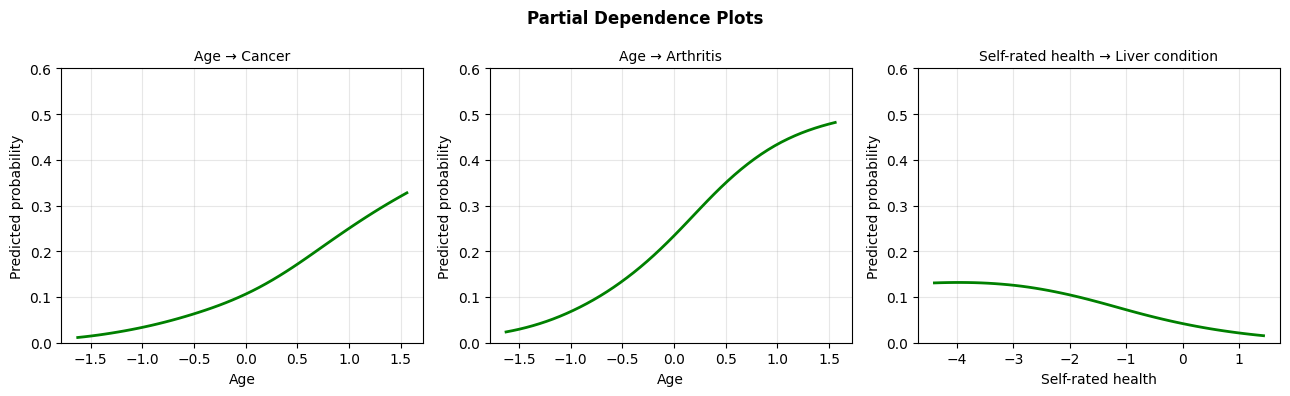

In [8]:
# Calculating some PDPs
test_X_t = torch.tensor(test_df[demo_cols].astype(float).values, dtype=torch.float32)
test_D_t = torch.tensor(test_df[disease_cols].astype(float).values, dtype=torch.float32)

def compute_pdp(model, X, D, feature_idx, n_grid=50, device='cpu'):
    """
    Sweeps feature_idx across its range, averages predictions over all samples.
    Returns (grid_vals, avg_preds) where avg_preds shape is (n_grid, K).
    """
    model.eval()
    grid = np.linspace(X[:, feature_idx].min().item(),
                       X[:, feature_idx].max().item(), n_grid)
    avg_preds = np.zeros((n_grid, D.shape[1]))

    with torch.no_grad():
        for g_idx, val in enumerate(grid):
            X_mod = X.clone()
            X_mod[:, feature_idx] = val
            preds = model(X_mod.to(device), D.to(device))
            avg_preds[g_idx] = preds.cpu().numpy().mean(axis=0)

    return grid, avg_preds

# three targeted PDPs
pdp_targets = [
    ('RIDAGEYR', 'MCQ220',  'Age',               'Cancer'),
    ('RIDAGEYR', 'MCQ160A', 'Age',               'Arthritis'),
    ('HUQ010',   'MCQ160L', 'Self-rated health', 'Liver condition'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (feat_col, disease_col, feat_name, disease_name) in zip(axes, pdp_targets):
    f_idx = demo_cols.index(feat_col)
    d_idx = disease_cols.index(disease_col)

    grid_vals, avg_preds = compute_pdp(model, test_X_t, test_D_t, f_idx, device=device)

    ax.plot(grid_vals, avg_preds[:, d_idx], color='green', lw=2)
    ax.set_xlabel(feat_name, fontsize=10)
    ax.set_ylabel('Predicted probability', fontsize=10)
    ax.set_title(f'{feat_name} → {disease_name}', fontsize=10)
    ax.set_ylim(0, 0.6)
    ax.grid(alpha=0.3)

fig.suptitle('Partial Dependence Plots', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('saved/pdp_selected.png', dpi=150, bbox_inches='tight')
plt.show()

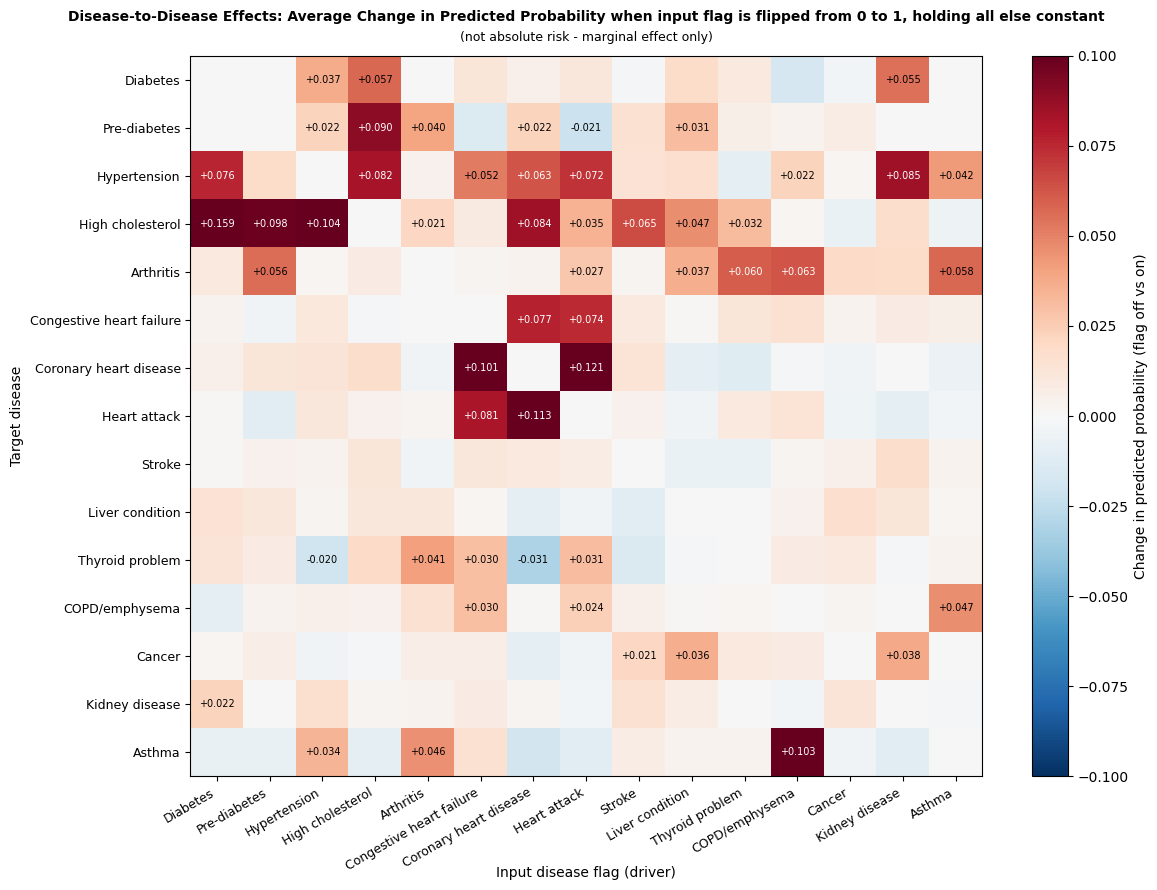

In [9]:
# Disease flag effects matrix
# shows how flipping each disease flag from 0 to 1 changes predicted probability
# for every other disease, red = raises probability, blue = lowers

flag_effects = np.zeros((len(disease_cols), len(disease_cols)))

model.eval()
with torch.no_grad():
    for f_idx, flag_col in enumerate(disease_cols):

        # set this disease flag to 0 for everyone
        D_off = test_D_t.clone()
        D_off[:, f_idx] = 0.0
        preds_off = model(test_X_t.to(device), D_off.to(device)).cpu().numpy()

        # set this disease flag to 1 for everyone
        D_on = test_D_t.clone()
        D_on[:, f_idx] = 1.0
        preds_on = model(test_X_t.to(device), D_on.to(device)).cpu().numpy()

        # effect = mean change in predicted prob when disease flag flipped on
        flag_effects[:, f_idx] = (preds_on - preds_off).mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(flag_effects, cmap='RdBu_r', aspect='auto',
               vmin=-0.1, vmax=0.1)

ax.set_xticks(range(len(disease_cols)))
ax.set_xticklabels(disease_names, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(disease_cols)))
ax.set_yticklabels(disease_names, fontsize=9)

# annotate cells big enough to matter
for i in range(len(disease_cols)):
    for j in range(len(disease_cols)):
        v = flag_effects[i, j]
        if abs(v) >= 0.02:
            col = 'white' if abs(v) > 0.06 else 'black'
            ax.text(j, i, f'{v:+.3f}', ha='center', va='center',
                    fontsize=7, color=col)

plt.colorbar(im, ax=ax, label='Change in predicted probability (flag off vs on)')
ax.set_xlabel('Input disease flag (driver)', fontsize=10, labelpad=-5)
ax.set_ylabel('Target disease', fontsize=10)
# main title bold
ax.set_title(
    'Disease-to-Disease Effects: Average Change in Predicted Probability when input flag is flipped from 0 to 1, holding all else constant',
    fontsize=10, fontweight='bold', pad=25
)
# add non-bold subtitle just below the main title
ax.text(0.5, 1.02, '(not absolute risk - marginal effect only)',
        transform=ax.transAxes, ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('saved/pdp_disease_effects.png', dpi=150, bbox_inches='tight')
plt.show()

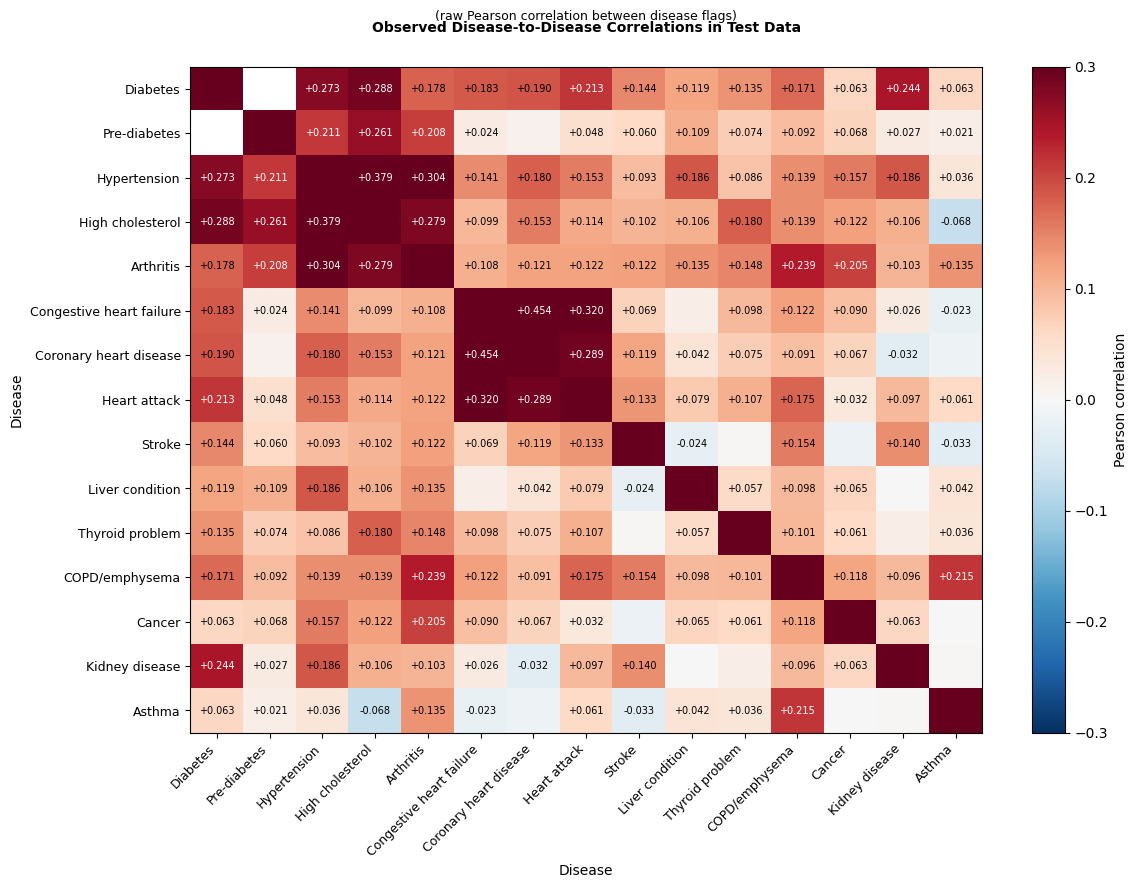

In [10]:
# Correlation Analysis
"""
Observed pairwise disease correlations in the raw test data
# comparing this to the model effects matrix shows whether the model
is recovering real comorbidity structure or something different
"""
disease_corr = test_df[disease_cols].corr().values

fig, ax = plt.subplots(figsize=(12, 9))

im = ax.imshow(disease_corr, cmap='RdBu_r', aspect='auto',
               vmin=-0.3, vmax=0.3)

ax.set_xticks(range(len(disease_cols)))
ax.set_xticklabels(disease_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(disease_cols)))
ax.set_yticklabels(disease_names, fontsize=9)

# annotate cells big enough to matter
for i in range(len(disease_cols)):
    for j in range(len(disease_cols)):
        v = disease_corr[i, j]
        if i != j and abs(v) >= 0.02: # skip diagonal (always 1.0)
            col = 'white' if abs(v) > 0.2 else 'black'
            ax.text(j, i, f'{v:+.3f}', ha='center', va='center',
                    fontsize=7, color=col)

plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_xlabel('Disease', fontsize=10)
ax.set_ylabel('Disease', fontsize=10)

# main title bold, subtitle not
ax.set_title(
    'Observed Disease-to-Disease Correlations in Test Data',
    fontsize=10, fontweight='bold', pad=25
)
ax.text(0.5, 1.07, '(raw Pearson correlation between disease flags)',
        transform=ax.transAxes, ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('saved/disease_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


/var/folders/h6/7yp_ymqd6mq5hrczq9ztfc580000gn/T/ipykernel_48765/2188225956.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_roc.show()
/var/folders/h6/7yp_ymqd6mq5hrczq9ztfc580000gn/T/ipykernel_48765/2188225956.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_pr.show()


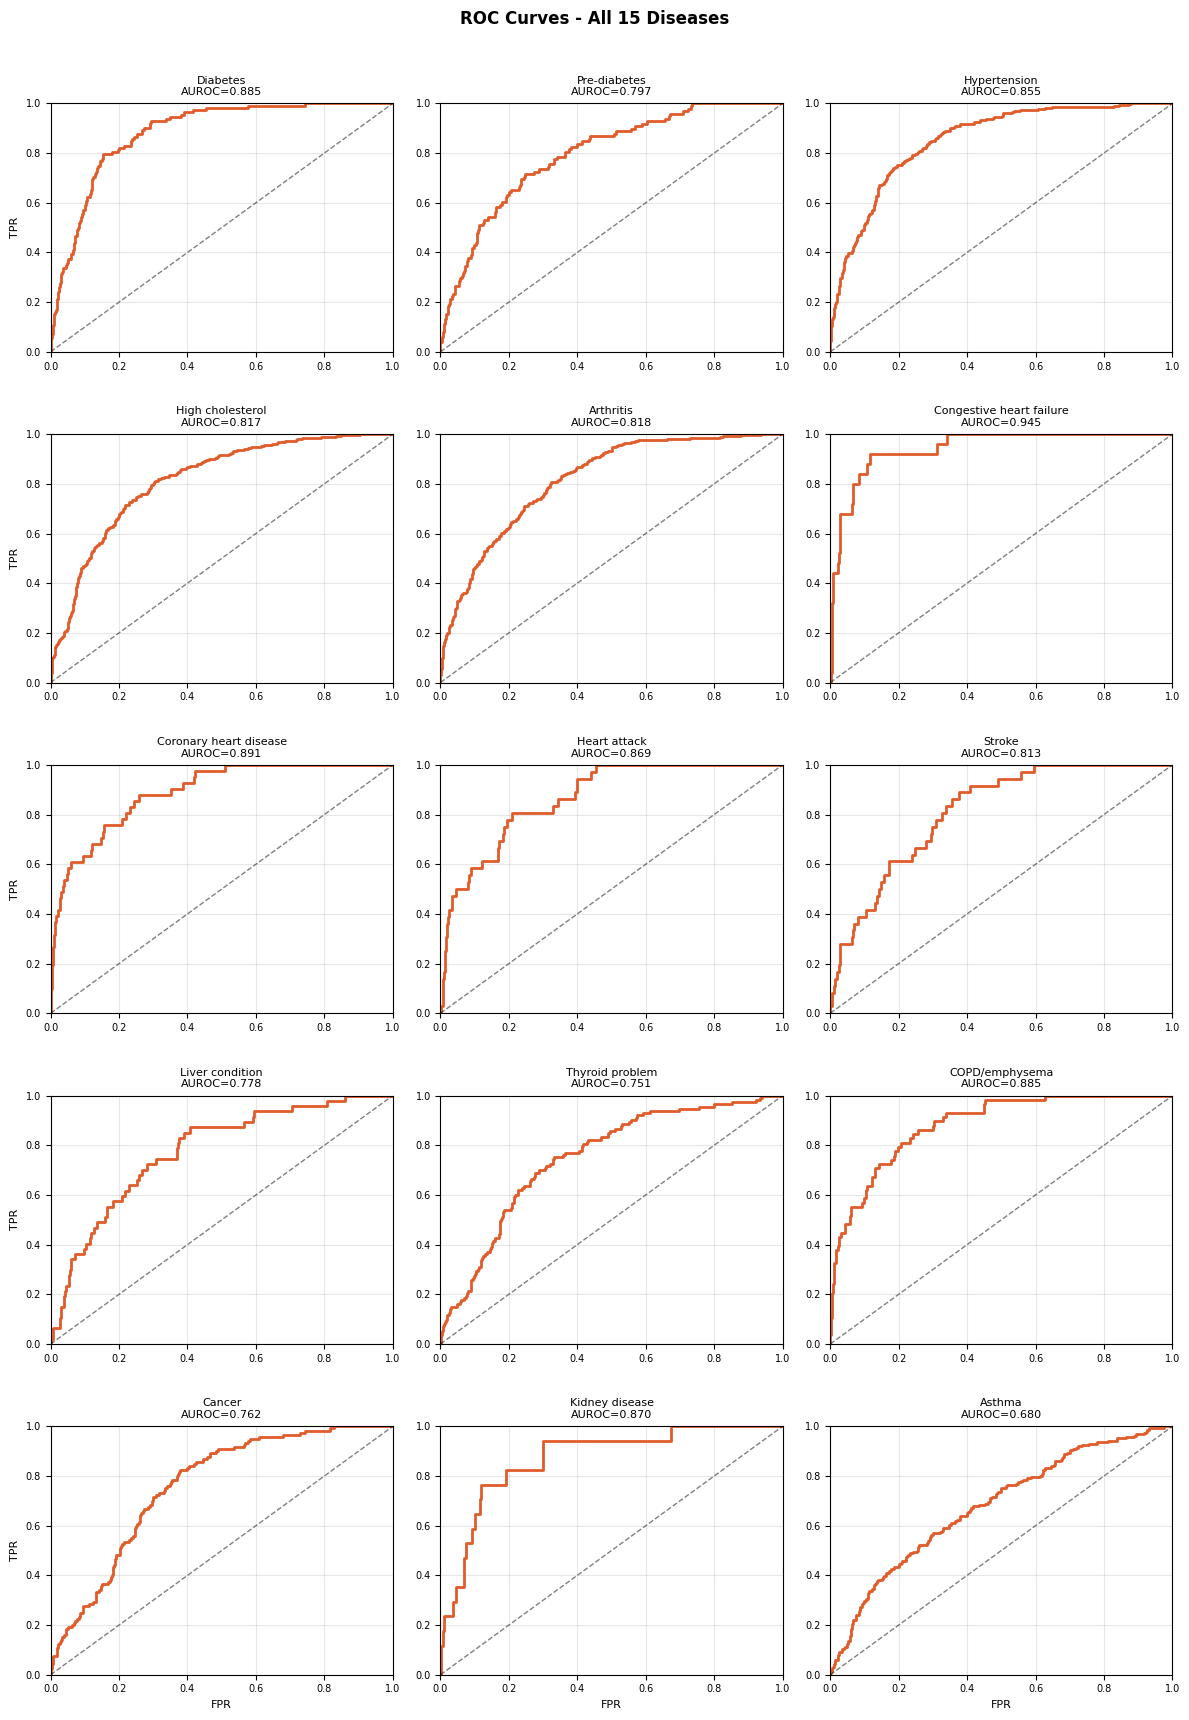

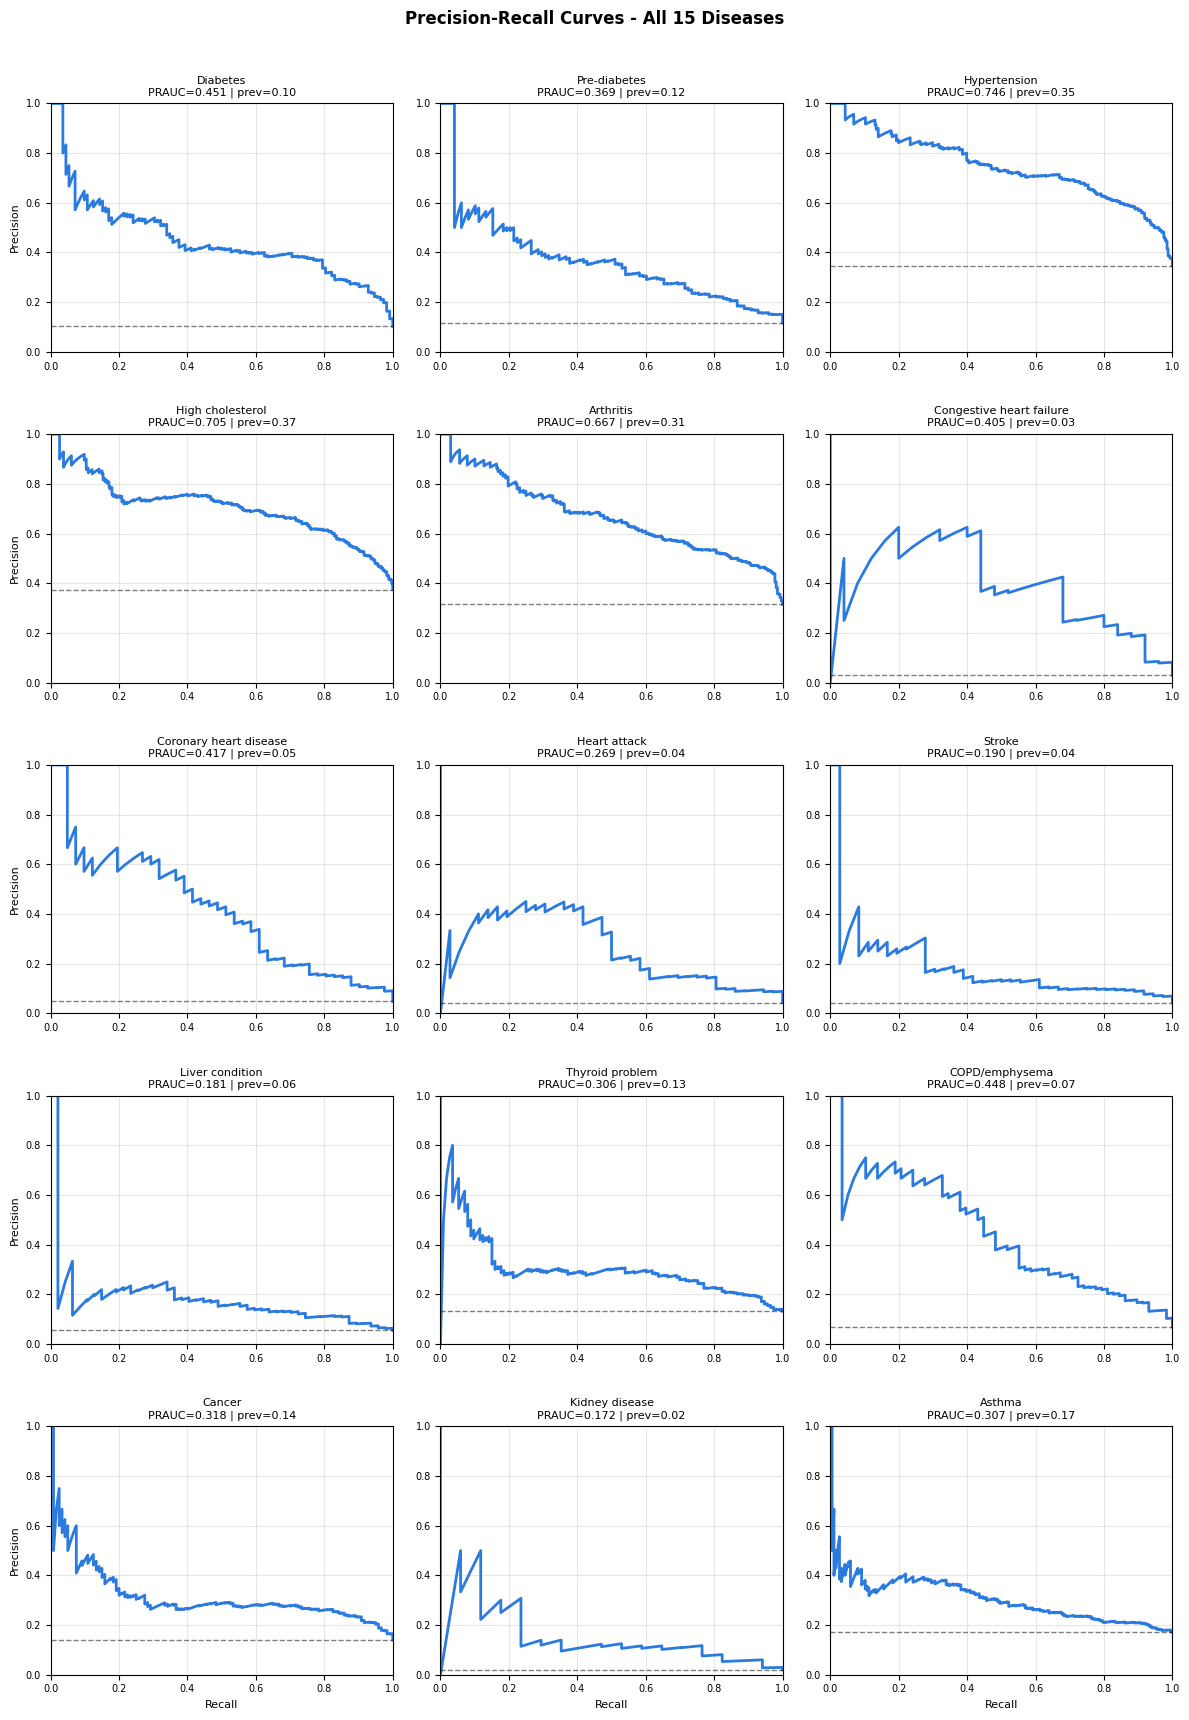

In [11]:
# ROC and PR curves for all 15 diseases in a grid
# standard in clinical ML papers, shows full threshold performance not just one point

from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

n_cols = 3
n_rows = 5  # 15 diseases, 3 per row

fig_roc, axes_roc = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
fig_pr,  axes_pr  = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))

for k, col in enumerate(disease_cols):
    row = k // n_cols
    col_pos = k % n_cols

    ax_roc = axes_roc[row, col_pos]
    ax_pr  = axes_pr[row, col_pos]

    # get valid samples for this disease
    valid = ~np.isnan(test_targets[:, k])
    t = test_targets[valid, k]
    p = test_preds[valid, k]

    prevalence = t.mean()

    # ROC curve
    fpr, tpr, _ = roc_curve(t, p)
    auroc = roc_auc_score(t, p)

    ax_roc.plot(fpr, tpr, color='#e05c2a', lw=2)
    ax_roc.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5) # random baseline
    ax_roc.set_xlim(0, 1)
    ax_roc.set_ylim(0, 1)
    ax_roc.set_title(f'{disease_meta[col]}\nAUROC={auroc:.3f}', fontsize=8)
    ax_roc.tick_params(labelsize=7)
    ax_roc.grid(alpha=0.3)

    # only label edges
    if row == n_rows - 1:
        ax_roc.set_xlabel('FPR', fontsize=8)
    if col_pos == 0:
        ax_roc.set_ylabel('TPR', fontsize=8)

    # PR curve
    prec, rec, _ = precision_recall_curve(t, p)
    prauc = average_precision_score(t, p)

    ax_pr.plot(rec, prec, color='#2a7ae0', lw=2)
    ax_pr.axhline(prevalence, color='k', linestyle='--', lw=1, alpha=0.5) # random baseline
    ax_pr.set_xlim(0, 1)
    ax_pr.set_ylim(0, 1)
    ax_pr.set_title(f'{disease_meta[col]}\nPRAUC={prauc:.3f} | prev={prevalence:.2f}', fontsize=8)
    ax_pr.tick_params(labelsize=7)
    ax_pr.grid(alpha=0.3)

    if row == n_rows - 1:
        ax_pr.set_xlabel('Recall', fontsize=8)
    if col_pos == 0:
        ax_pr.set_ylabel('Precision', fontsize=8)

fig_roc.suptitle('ROC Curves - All 15 Diseases', fontsize=12, fontweight='bold')
fig_roc.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.5)
fig_roc.savefig('saved/roc_curves.png', dpi=150, bbox_inches='tight')
fig_roc.show()

fig_pr.suptitle('Precision-Recall Curves - All 15 Diseases', fontsize=12, fontweight='bold')
fig_pr.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.5)
fig_pr.savefig('saved/pr_curves.png', dpi=150, bbox_inches='tight')
fig_pr.show()